In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

import ladder
plt.close()

In [3]:
pull_predictions_from_weka("consistent_ranking")

Downloading: 100%|█████████████████████████| 10.1G/10.1G [24:18<00:00, 6.94MB/s]


In [ ]:
# load a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'correct_choice'] # accuracy benchmarks

COLS += ['logits_per_byte', 'logits_per_byte_corr', 'logits_per_char_corr']

df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)
print(f'Loaded {len(df):,} instance predictions')

Loaded 114,520,000 instance predictions


In [8]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
SIZES  = df['size'].unique()
TOKEN_RATIO = df['token_ratio'].unique()

MMLU  = [t for t in TASKS if 'mmlu' in t]
TASKS = [t for t in TASKS if 'mmlu' not in t and ':para' not in t]
TASKS = sorted(TASKS)

### Running the Model Ladder

In [9]:
ladder_config_path = f'{ROOT_DIR}/olmo-repos/OLMo/scripts/scaling/cheap_decisions.json'

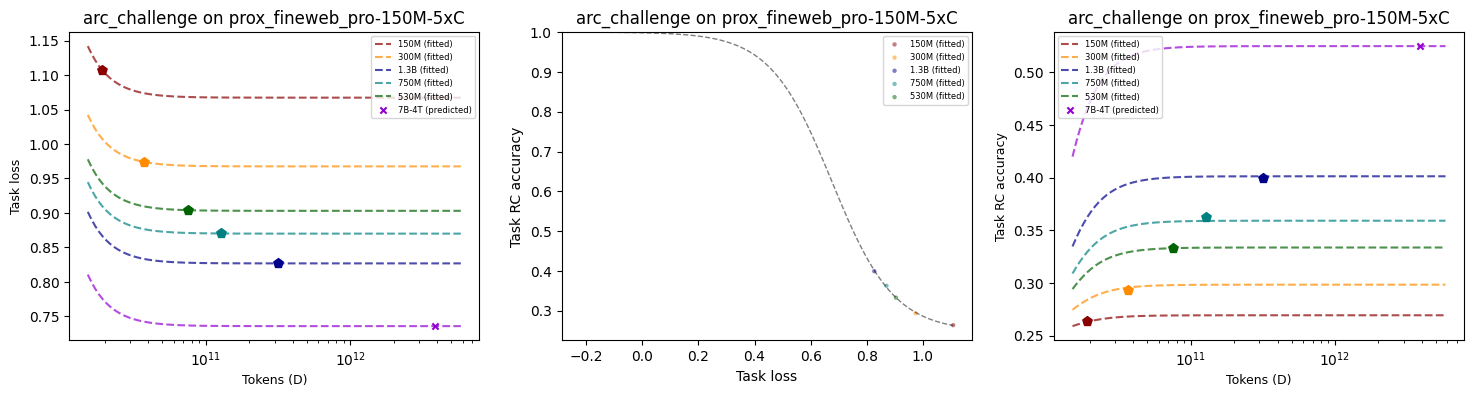

In [17]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "arc_challenge"
example_models = [m for m in MODELS if 'prox_fineweb_pro' in m]
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=example_models,
    # eval_models=["peteish7", "peteish13-highlr"],
    eval_models=["peteish7"],
    # eval_models=[],
    config_path=ladder_config_path,
    axes=axes[0],
)

for ax in axes[0]:
    ax.set_title(f'{task_name} on {example_models[0]}')

Fitting model ladder predictions:  44%|████▍     | 4/9 [00:01<00:01,  2.57it/s]/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling/step1.py:160: RuntimeWarning: overflow encountered in exp
  A, B = np.exp(a), np.exp(b)
/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling/predict.py:108: RuntimeWarning: overflow encountered in exp
  A, B = np.exp(a), np.exp(b)
Fitting model ladder predictions: 100%|██████████| 9/9 [00:03<00:00,  2.57it/s]


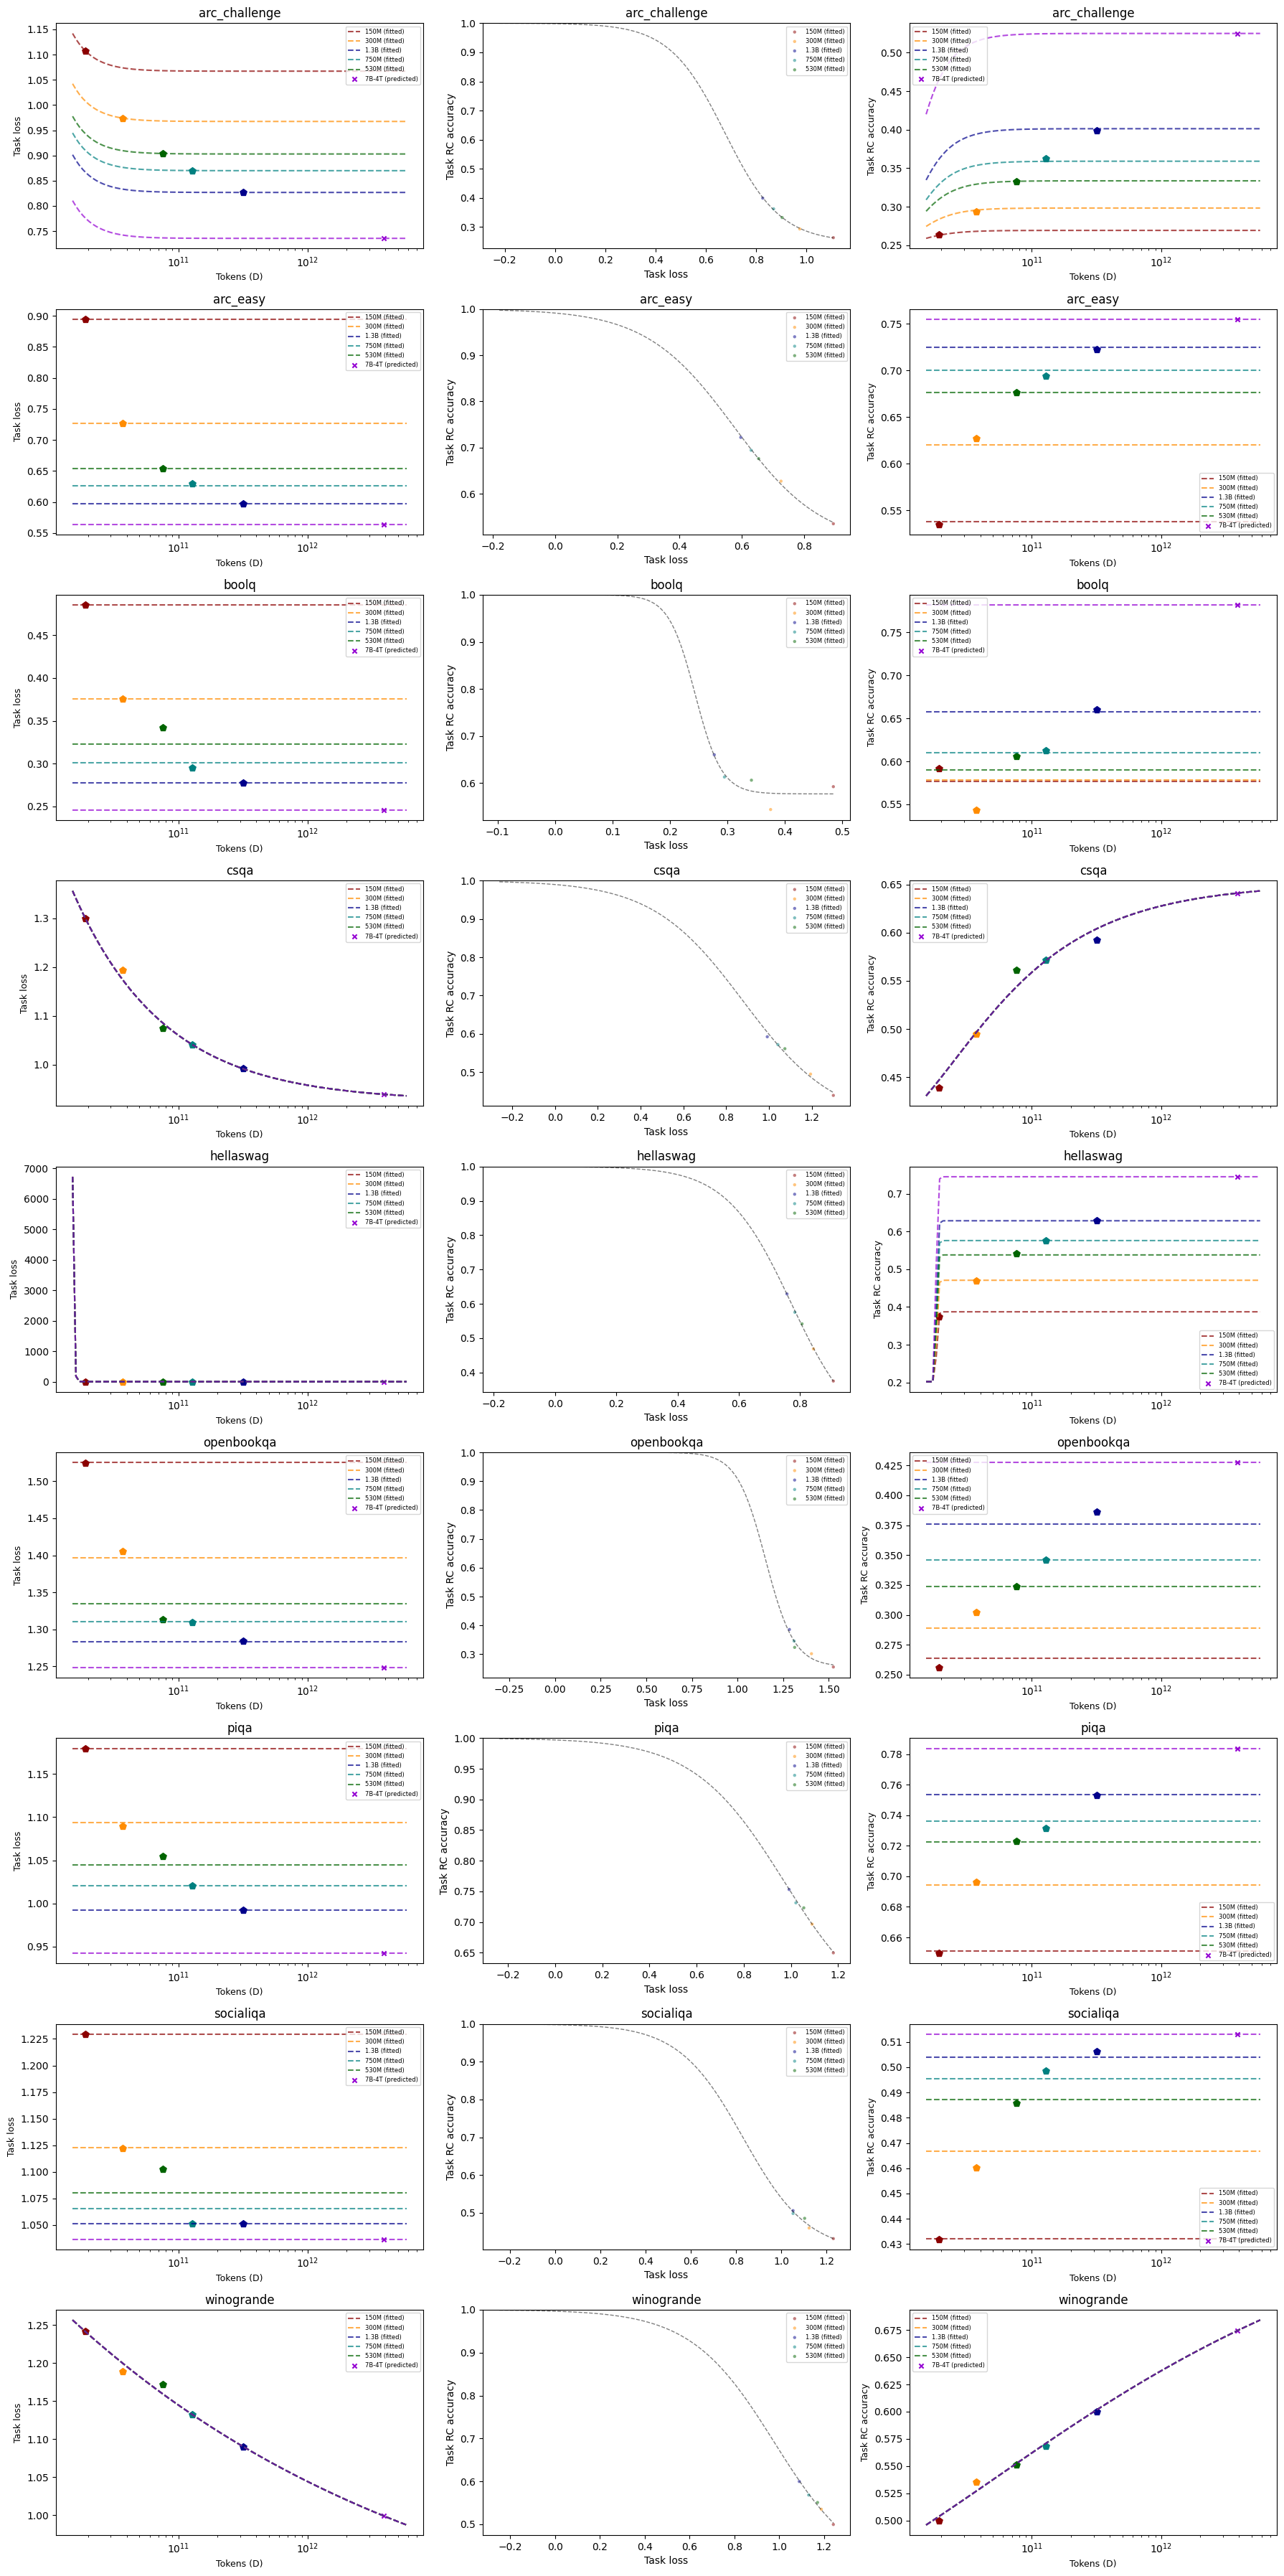

In [18]:
from tqdm import tqdm

num_rows, num_cols = len(TASKS), 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=[], columns=TASKS)

for i, task in tqdm(enumerate(TASKS), desc='Fitting model ladder predictions', total=len(TASKS)):
    try:
        _, _, _ = run_ladder(
            df,
            task_name=task,
            train_models=example_models,
            eval_models=["peteish7"], # ["peteish13-highlr"],
            config_path=ladder_config_path,
            axes=axes[i],
        )
    except Exception as e:
        print(f'{task} failed: {e}')
        continue

fig.tight_layout()

### Results on All Mixes

In [19]:
from tqdm import tqdm

fitting_results = pd.DataFrame(index=[], columns=TASKS)

for mix in tqdm(MIXES, desc='Fitting model ladder predictions', total=len(MIXES)):
    models = [model for model in MODELS if '-'.join(model.split('-')[:-2]) == mix]

    for i, task in enumerate(TASKS):
        _, _, pred_acc = run_ladder(
            df,
            task_name=task,
            train_models=models,
            eval_models=["peteish7"], # ["peteish13-highlr"],
            config_path=ladder_config_path,
            return_preds=True
        )

        fitting_results.loc[mix, task] = pred_acc

Fitting model ladder predictions:  40%|████      | 8/20 [00:28<00:44,  3.73s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:374: RuntimeWarning: overflow encountered in scalar power
  grad_x0 = p[0] * p[2] * exp_term / (denom**2)
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:375: RuntimeWarning: overflow encountered in scalar power
  grad_k = p[0] * (x - p[1]) * exp_term / (denom**2)
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:374: RuntimeWarning: overflow encountered in scalar power
  grad_x0 = p[0] * p[2] * exp_term / (denom**2)
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:375: RuntimeWarning: overflow encountered in scalar power
  grad_k = p[0] * (x - p[1]) * exp_term / (denom**2)
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered

In [20]:
print('Predicted performance for 7B-4T on all mixes:')
fitting_results['macro_avg'] = fitting_results.mean(axis=1)
fitting_results = fitting_results.sort_values(by='macro_avg', ascending=False)
fitting_results_display = fitting_results.map(lambda x: f'{round(x * 100, 1)}%')
fitting_results_display

Predicted performance for 7B-4T on all mixes:


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,macro_avg
falcon_and_cc_og_eli5_oh_top10p,52.1%,78.6%,99.9%,68.1%,70.3%,41.8%,82.4%,52.8%,70.0%,68.5%
falcon_and_cc_eli5_oh_top20p,53.5%,83.2%,83.2%,71.6%,75.0%,40.2%,83.1%,54.7%,67.8%,68.0%
falcon,42.1%,75.9%,97.6%,61.4%,72.9%,40.0%,81.1%,65.3%,65.9%,66.9%
dolma17-50p-DCLM-baseline-50p,54.8%,78.4%,61.0%,59.9%,72.4%,54.0%,80.6%,64.5%,70.3%,66.2%
dolma17-25p-DCLM-baseline-75p,51.8%,79.9%,61.7%,63.2%,76.3%,46.5%,80.9%,57.0%,69.2%,65.2%
prox_fineweb_pro,52.5%,75.5%,78.2%,64.1%,74.5%,42.7%,78.4%,51.3%,67.5%,65.0%
no_flan,42.5%,78.0%,76.3%,74.4%,71.5%,38.1%,75.8%,54.9%,70.6%,64.7%
fineweb_edu_dedup,49.1%,74.7%,73.0%,75.3%,70.1%,40.2%,77.8%,54.3%,67.2%,64.6%
DCLM-baseline,43.8%,74.1%,73.3%,64.9%,75.2%,40.9%,83.8%,57.0%,63.3%,64.1%
falcon_and_cc_tulu_qc_top10,45.0%,78.5%,69.9%,70.8%,72.1%,39.9%,77.6%,56.5%,63.5%,63.8%
